In [1]:
import numpy as np
import getdist
from getdist import plots
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import argparse
import os
import glob
from typing import List, Dict, Optional, Tuple
import warnings
import yaml

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
import os
dirname = os.getcwd()
print(dirname)
if os.getcwd().endswith("cosmosis-standard-library" + os.path.sep + "examples_rose" + os.path.sep + "notebooks"):
    print("Switching to directory cosmosis-standard-library")
    os.chdir(os.path.pardir)
    os.chdir(os.path.pardir)

/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library/examples_rose/plotting_scripts
Switching to directory cosmosis-standard-library


In [3]:
dirname = os.getcwd()
print(dirname)

/Users/s2265800/Desktop/Work/cosmosis_stuff/cosmosis-standard-library


In [ ]:
# Load parameter configuration files
# params_names.yaml contains the mapping from parameter names to LaTeX labels

with open("examples_rose/notebooks/fiducials_cmb_w0wa_full.yaml", "r") as file:
    fiducial_dic = yaml.safe_load(file)
    fiducials = {k: v['p0'] for k, v in fiducial_dic.items()}
    params_dic = {k: v['latex'] for k, v in fiducial_dic.items()}
    ranges = {k: v['range'] for k, v in fiducial_dic.items()}

In [26]:
chain_files = ['output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.05_iteration_1.txt',
               'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.2875_iteration_2.txt',
               'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.525_iteration_3.txt',
               'output/rose_desi_pantheon/chain_rose_desi_pantheon_tempering_0.7625_iteration_4.txt',
               'output/rose_desi_pantheon/chain_rose_desi_pantheon.txt',
               'output/nautilus_desi_pantheon/chain_nautilus_desi_pantheon.txt'
]

In [27]:
def read_first_header_line(file_path):
    """
    Extract parameter names from the first header line of a chain file.
    
    The first header line contains the parameter names.

    Parameters:
    -----------
    file_path : str
        Path to the MCMC chain file
        
    Returns:
    --------
    list
        List of parameter names extracted from the header, or empty list if no header found
        
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        
    # Extract the first header line (remove '#' and whitespace, then split)
    if first_line:
        first_header = first_line.strip('#').strip()
        if first_header:
            #return [param.split('--')[-1] if '--' in param else param for param in first_header.split()]
            return [param for param in first_header.split()]
    return []

# =============================================================================
# DATA LOADING SECTION
# =============================================================================

n_samples = len(chain_files)
chains_info = {}

# Load each MCMC chain file
for i in range(n_samples):
    file_path = chain_files[i]  
    
    # Load numerical data from chain file
    chain = np.genfromtxt(file_path)
    
    # Extract parameter names from header
    chain_pars = read_first_header_line(file_path)
    
    # Remove last two columns (typically log-likelihood and weight)
    chain_pars = chain_pars[:-4] if i != n_samples-1  else chain_pars[:-3]
    print(chain_pars)
    # Store chain data and parameter names
    chains_info[i] = {}
    chains_info[i]['chain'] = chain[:,:len(chain_pars)]
    #assuming that the last chain is done with Nautilus while the others are done with emcee
    weights = np.exp(chain[:, -3]) if i == (n_samples-1) else np.exp(chain[:, -1]) 
    chains_info[i]['weights'] = weights
    chains_info[i]['pars'] = chain_pars

['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmological_parameters--h0', 'cosmological_parameters--w', 'cosmological_parameters--wa', 'supernova_params--m']
['cosmological_parameters--omch2', 'cosmological_parameters--ombh2', 'cosmologic

In [28]:
# =============================================================================
# GETDIST SAMPLE PREPARATION
# =============================================================================

samples = []    
for i in range(n_samples):
    # Create GetDist MCSamples object for each chain
    if i == n_samples-1 or i == n_samples-2:
        samples.append(
            getdist.MCSamples(
                # Sample data (excluding log-likelihood and weight columns)
                samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                # Parameter names
                names = [i for i in chains_info[i]['pars']],
                # Sample weights (exponential of log-likelihood)
                weights=chains_info[i]['weights'],
                # LaTeX labels for parameters (from params_dic)
                labels = [params_dic[p] for p in chains_info[i]['pars']],
                # Parameter ranges for plotting
                #ranges = ranges
            ) 
            )
    else:
        samples.append(
            getdist.MCSamples(
                # Sample data (excluding log-likelihood and weight columns)
                samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                # Parameter names
                names = [i for i in chains_info[i]['pars']],
                # Sample weights (exponential of log-likelihood)
                weights= None,
                # LaTeX labels for parameters (from params_dic)
                labels = [params_dic[p] for p in chains_info[i]['pars']],
                # Smoothing settings for 1D and 2D distributions
                settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                #settings={'smooth_scale_2D':0.25, 'smooth_scale_1D':0.25},
                # Parameter ranges for plotting
                #ranges = ranges
            ) 
            )

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


In [29]:
# Load training data if provided
training_data_in = 'output/rose_desi_pantheon/rose_outputs/total_training_set.npz'
trainset = np. load(training_data_in)
for key in trainset.keys():
    print(key)
print(trainset['points_per_iteration'])

cosmological_parameters--omch2
cosmological_parameters--omch2--norm
cosmological_parameters--ombh2
cosmological_parameters--ombh2--norm
cosmological_parameters--h0
cosmological_parameters--h0--norm
cosmological_parameters--w
cosmological_parameters--w--norm
cosmological_parameters--wa
cosmological_parameters--wa--norm
supernova_params--m
supernova_params--m--norm
features/desi_bao
features/pantheon
fixed_keys
fixed_features
output_keys
likelihood_names
features_size
features
chi2
priors
posts
points_per_iteration
[80 40 40 40 40]


Plotting iteration 1: cosmological_parameters--w vs cosmological_parameters--wa
  Successfully plotted contours for iteration 1
80
  Added 80 training data points
Plotting iteration 2: cosmological_parameters--w vs cosmological_parameters--wa
  Successfully plotted contours for iteration 2
120
  Added 120 training data points
Plotting iteration 3: cosmological_parameters--w vs cosmological_parameters--wa
  Successfully plotted contours for iteration 3
160
  Added 160 training data points
Plotting iteration 4: cosmological_parameters--w vs cosmological_parameters--wa
  Successfully plotted contours for iteration 4
200
  Added 200 training data points
Plotting iteration 5: cosmological_parameters--w vs cosmological_parameters--wa
  Successfully plotted contours for iteration 5
240
  Added 240 training data points


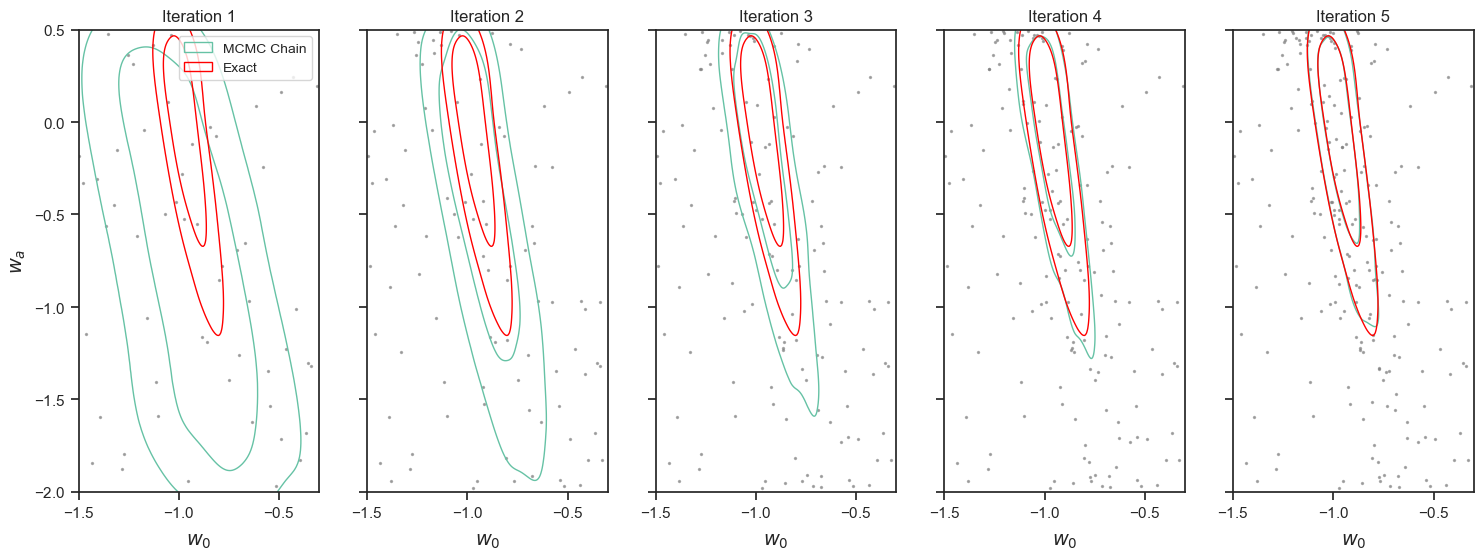

<Figure size 350x262.5 with 0 Axes>

In [32]:

title = "Posterior Progression",
# Set up plotting style and colors
import seaborn as sns
sns.set_theme(style="ticks")
colors = sns.color_palette("Set2")  # Use seaborn Set2 color palette

show_training_points = True
training_points_per_iteration = trainset['points_per_iteration']
figsize = (18, 6)



chain_pars = ['cosmological_parameters--w', 'cosmological_parameters--wa']
params_dic = {'cosmological_parameters--w': 'w_0', 'cosmological_parameters--wa': 'w_a'}
# Create a figure with horizontal subplots (exact same as original)
fig, axes = plt.subplots(1, n_samples-1, figsize=figsize, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)

# Make a base plotter without subplot management (exact same as original)
g = plots.get_single_plotter(width_inch=3.5)

# Create legend handles (exact same as original)
legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor=colors[0], linestyle='-', label='MCMC Chain'),
    mpatches.Patch(facecolor='none', edgecolor='red', linestyle='-', label='Exact')
]

# Loop through each subplot (exact same as original)
for i in range(n_samples-1):
    ax = axes[i]
    
    xparam = chain_pars[0]
    yparam = chain_pars[1]
    
    print(f"Plotting iteration {i+1}: {xparam} vs {yparam}")
    
    # Plot on the specified axis (exact same as original)
    g.plot_2d(samples[i], xparam, yparam, 
                contour_args=[{'filled': False, 'color': colors[0], 'ls': '-'}],
                ax=ax)
    # Plot on the specified axis (exact same as original)
    g.plot_2d(samples[-1], xparam, yparam, 
                contour_args=[{'filled': False, 'color': 'red', 'ls': '-'}],
                ax=ax)
    print(f"  Successfully plotted contours for iteration {i+1}")
    
    # Set the y-label and legend only for the first subplot (exact same as original)
    if i == 0:
        ax.set_ylabel('$' + params_dic[yparam] + '$')
        ax.legend(handles=legend_handles, loc='upper right', fontsize=10)
    else:
        ax.set_ylabel('')
    
    # Add training data points if available
    if show_training_points and xparam in trainset and yparam in trainset:
        x_data = trainset[xparam]
        y_data = trainset[yparam]
        
        # Calculate how many points to show for this iteration
        n_points = sum(training_points_per_iteration[:i+1])
        print(n_points)
        n_points = min(n_points, len(x_data))
        
        ax.scatter(x_data[:n_points], y_data[:n_points], 
                    s=2, color='grey', alpha=0.6)
        print(f"  Added {n_points} training data points")
    
    # Set axis labels and title (exact same as original)
    ax.set_xlabel('$' + params_dic[xparam] + '$')
    ax.set_title(f'Iteration {i+1}')
    ax.set_xlim(-1.5, -0.3)
    ax.set_ylim(-2., 0.5)
# Adjust layout and save (exact same as original)
plt.suptitle(title, fontsize=16)
plt.tight_layout()
plt.show()